In [1]:
import sys
import os

# Get the current working directory
cwd = os.getcwd()
print(f"Current Working Directory: {cwd}")

# Define the path to the 'mapelite' folder
# We assume the notebook is running from the root 'Quality-Diversity-...' folder
mapelite_path = os.path.join(cwd, 'mapelite')

# Add it to the system path so Python can find config.py, utils.py, etc.
if mapelite_path not in sys.path:
    sys.path.append(mapelite_path)
    print(f"Added '{mapelite_path}' to sys.path")

Current Working Directory: d:\dev\Quality-Diversity-for-Racing-Track-Design
Added 'd:\dev\Quality-Diversity-for-Racing-Track-Design\mapelite' to sys.path


In [2]:
import numpy as np
import random
import os

from ribs.archives import ProximityArchive
from ribs.schedulers import Scheduler

from emitter import CustomEmitter
from mapelite.qd_runner import QDRunner

d:\dev\Quality-Diversity-for-Racing-Track-Design\mapelite\qd_runner.py:141: SyntaxWarning: invalid escape sequence '\e'
  "mapelite\embeddings\models\model_metrics_VAE_latent32_umap.joblib")
d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from mapelite.config import (
    SOLUTION_DIM,
    BATCH_SIZE,
    NS_DIR,
    BUFFER_FILENAME,
    CHECKPOINT_DIR,
    STATS_FILENAME,
    ELITES_FILENAME,
    HEATMAP_DIR,
    GRIDPLOT_DIR,
    INVALID_SCORE,
    ITERATIONS,
    EMBEDDING_MODEL_PATH
)

# --- Novelty Search specific config ---
checkpoint_dir = os.path.join(NS_DIR, CHECKPOINT_DIR)
heatmap_dir = os.path.join(NS_DIR, HEATMAP_DIR)
gridplot_dir = os.path.join(NS_DIR, GRIDPLOT_DIR)
stats_path = os.path.join(NS_DIR, STATS_FILENAME)
buffer_path = os.path.join(NS_DIR, BUFFER_FILENAME)

EMBEDDING_DIM = 32
DEFAULT_THRESHOLD = 5
SEED = 67
ELITES_OUTPUT = os.path.join(NS_DIR, ELITES_FILENAME)
ALGORITHM_LABEL = "Novelty Search (ProximityArchive + local competition)"

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)


In [10]:

# --- Calculate a good novelty threshold from the embedding dataset ---
# Fits k-NN (same k as the archive) on the pre-existing embeddings and
# reports percentile distances so you can pick an informed threshold.

from sklearn.neighbors import NearestNeighbors

_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS.npz"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]  # (N, 32)

_k = 15  # same as archive k_neighbors
_nbrs = NearestNeighbors(n_neighbors=_k + 1).fit(_embeddings)
_dists, _ = _nbrs.kneighbors(_embeddings)
_knn_mean_per_point = _dists[:, 1:].mean(axis=1)  # exclude self (col 0)

print(f"Dataset: {len(_embeddings)} embeddings  |  k={_k}")
print(f"  Mean k-NN dist : {_knn_mean_per_point.mean():.4f}")
for _p in (5, 10, 25, 50, 75):
    print(f"  {_p:2d}th percentile: {np.percentile(_knn_mean_per_point, _p):.4f}")

# Use the 10th percentile: low enough for a selective archive, but not so
# tight that only outliers enter.  Adjust by raising/lowering the percentile.
DEFAULT_THRESHOLD = float(np.percentile(_knn_mean_per_point, 10))
print(f"\n→ DEFAULT_THRESHOLD set to {DEFAULT_THRESHOLD:.4f}  (10th percentile)")


Dataset: 19154 embeddings  |  k=15
  Mean k-NN dist : 2.1516
   5th percentile: 1.8412
  10th percentile: 1.8954
  25th percentile: 1.9982
  50th percentile: 2.1310
  75th percentile: 2.2820

→ DEFAULT_THRESHOLD set to 1.8954  (10th percentile)


In [4]:
# --- Initialize directories ---
os.makedirs(NS_DIR, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(heatmap_dir, exist_ok=True)
os.makedirs(gridplot_dir, exist_ok=True)

# --- DASK SETUP ---
client, cluster, evaluator_future = QDRunner.setup_dask(BATCH_SIZE, model_path=EMBEDDING_MODEL_PATH)

Setting up Dask LocalCluster...
Dask Dashboard link: http://127.0.0.1:8787/status
Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng.pth...
Model loaded with latent_dim=32
Evaluator scattered to 10 Dask workers


In [5]:
# --------------------------------------------------------------
# Resume from latest checkpoint if available,
# otherwise build archive from scratch
# --------------------------------------------------------------
state = QDRunner.resume_from_checkpoint(checkpoint_dir, stats_path)

if state["scheduler"] is not None:
    scheduler = state["scheduler"]
    archive   = state["archive"]
else:
    archive = ProximityArchive(
        solution_dim=SOLUTION_DIM,
        measure_dim=EMBEDDING_DIM,
        k_neighbors=15,
        novelty_threshold=DEFAULT_THRESHOLD,
        seed=SEED,
        local_competition=True
    )

    emitter = CustomEmitter(
        archive,
        solution_dim=SOLUTION_DIM,
        batch_size=BATCH_SIZE,
        bounds=[(0, 600)] * (SOLUTION_DIM - 1) + [(0, float("inf"))]
    )

    scheduler = Scheduler(archive, [emitter])
    print("Archive, emitter, and scheduler created.")

# --- Build the QDRunner ---
runner = QDRunner(
    scheduler=scheduler, archive=archive, client=client,
    evaluator_future=evaluator_future,
    checkpoint_dir=checkpoint_dir, heatmap_dir=heatmap_dir,
    gridplot_dir=gridplot_dir, stats_path=stats_path,
    buffer_path=buffer_path, seed=SEED,
)
runner.load_state(
    start_iter=state["start_iter"],
    global_best_score=state["global_best_score"],
    global_best_id=state["global_best_id"],
    stats=state["stats"],
)

[Resume] Loaded data/ns/checkpoints\checkpoint_0300.pkl, resuming from iteration 301
[Resume] Resumed stats with 300 entries
[Buffer] Resumed 3000 entries from data/ns/buffer.json


In [6]:
# print ribs version
import ribs
print(f"Ribs version: {ribs.__version__}")

Ribs version: 0.8.1


In [7]:
# Run main loop
global_best_score, global_best_id, stats = runner.run(
    total_iters=ITERATIONS,
    start_iter=state["start_iter"],
)

Emitter.ask() called for iteration 301
Mutating solutions for iteration 301
[timing] ask+convert: 0.107s
[timing] dask evaluate (10 solutions): 37.436s
Solution ID=300.56741559769057 evaluated with score=19.00
Solution ID=300.9681513111597 evaluated with score=9.50
Solution ID=300.1212756681612 evaluated with score=15.00
Solution ID=300.8204755540389 evaluated with score=15.50
Solution ID=300.75397744813387 evaluated with score=18.00
Solution ID=300.3277751949323 evaluated with score=26.75
Solution ID=300.15343912837557 evaluated with score=10.00
Solution ID=300.8050138158315 evaluated with score=8.50
Solution ID=300.03391531951064 evaluated with score=21.00
[timing] result processing+buffer: 0.000s
[timing] pre-tell snapshot: 0.000s
[timing] tell: 0.508s
Iteration 301 ended. Best in batch = 26.75
Global best so far: 44.25 (ID=16.119370379340964)
Archive Updates: 0 new elites inserted, 1 elites substituted.
Archive size=43, mean=23.55, best=44.25
Mean WSS/track = 10.1951
[timing] wss: 

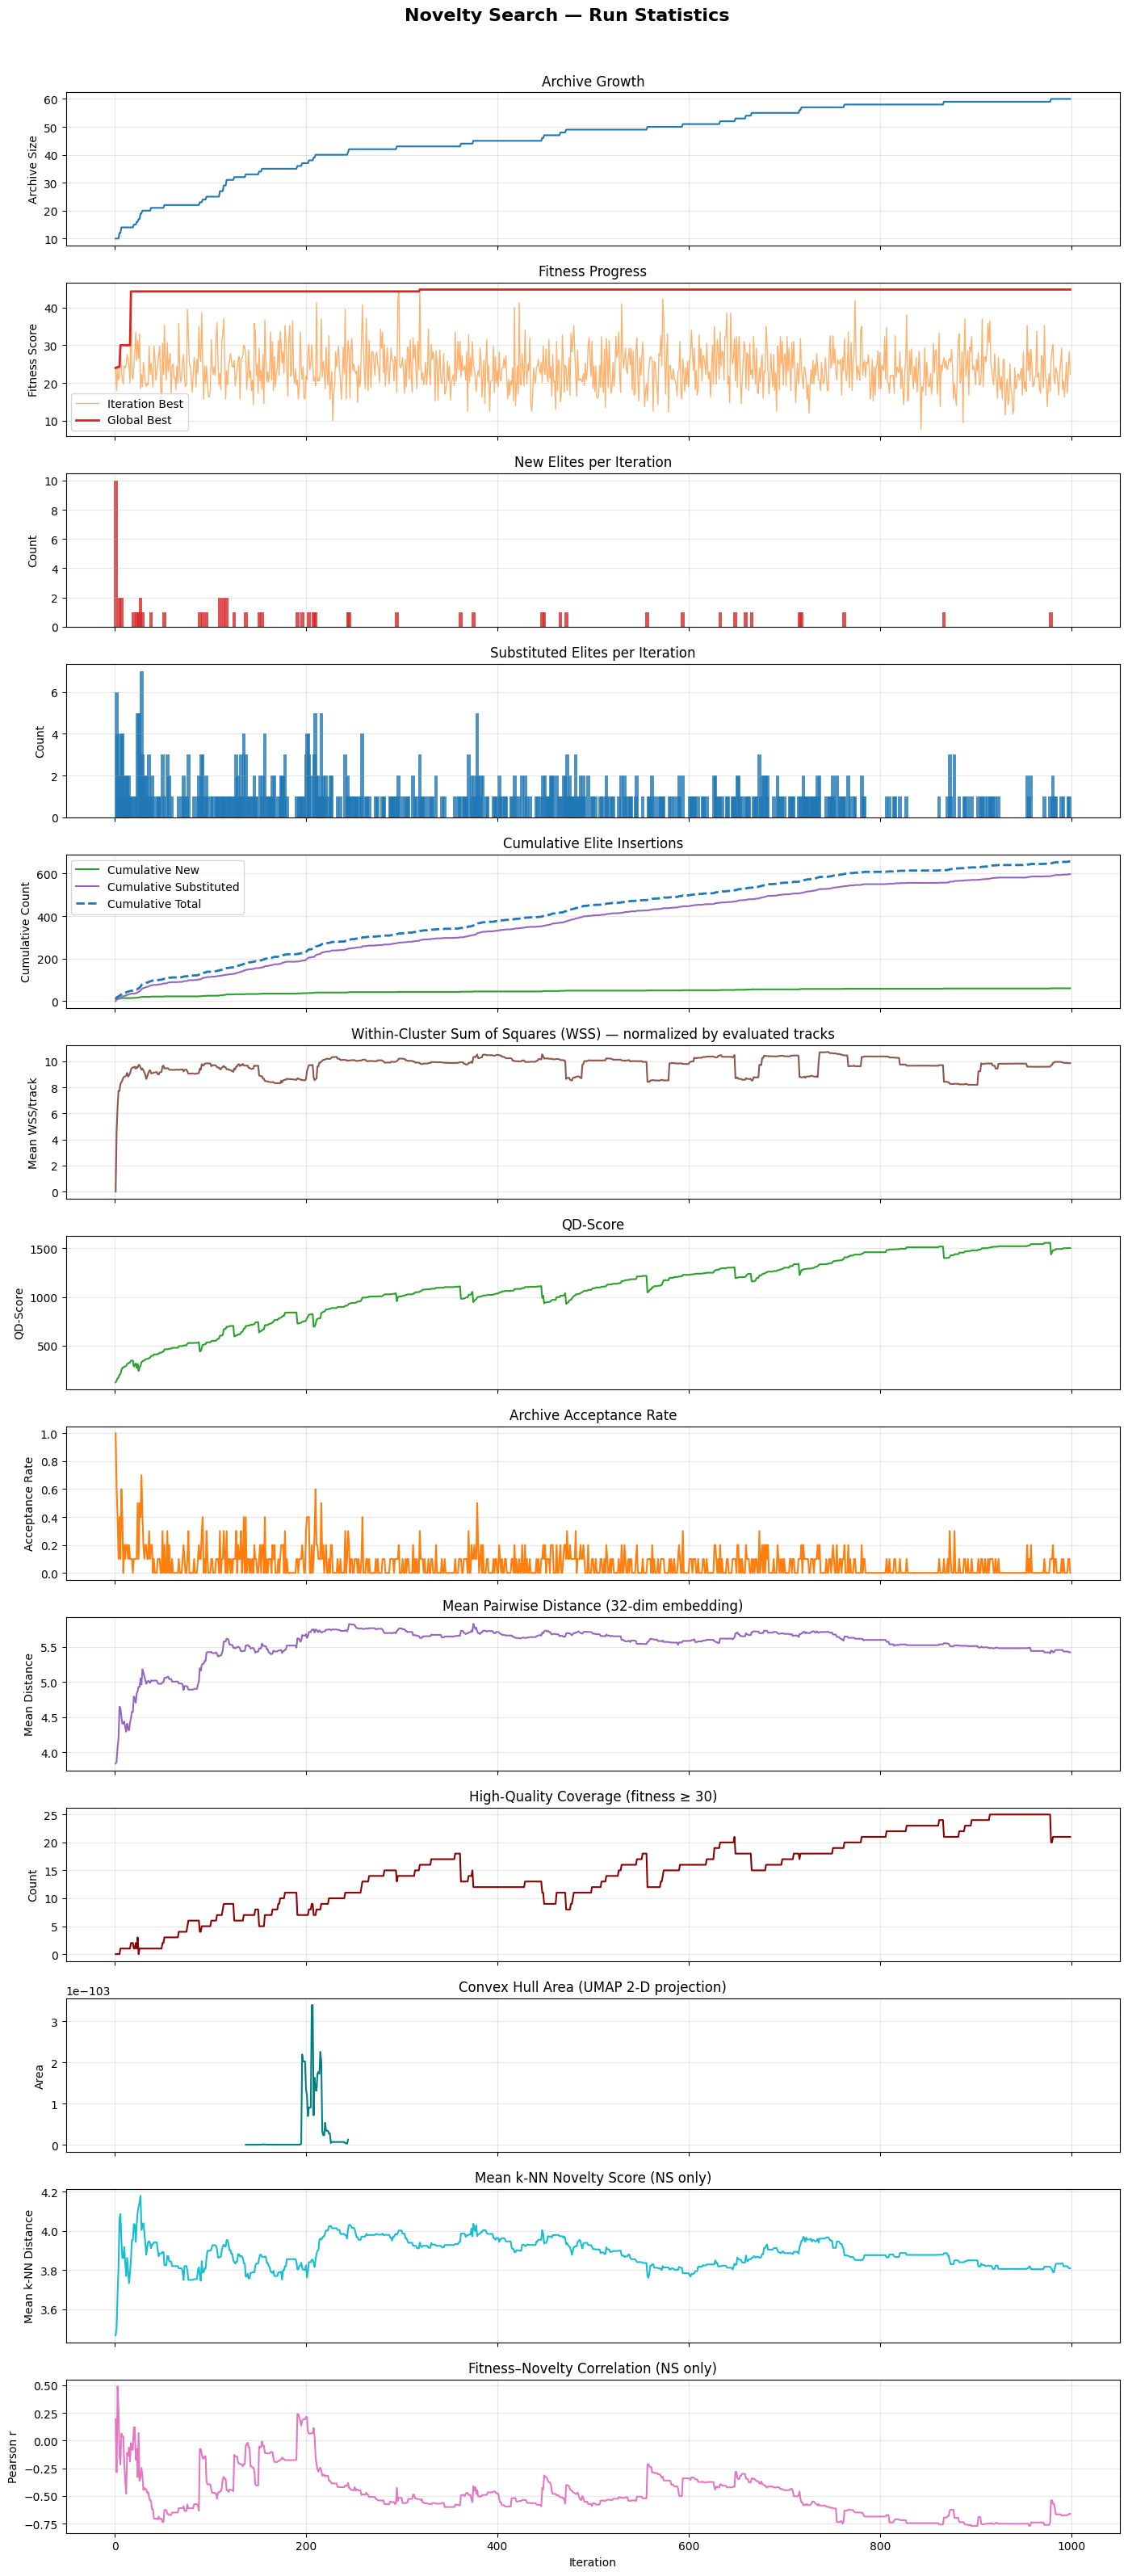


  Novelty Search Summary
  Total iterations:        999
  Final archive size:      60
  Global best fitness:     44.7500
  Total new elites:        60
  Total substituted:       597
  Avg new elites/iter:     0.06
  Avg substituted/iter:    0.60


In [8]:
runner.visualizer.plot_stats(title="Novelty Search")

In [9]:
runner.visualizer.export_elites(
    output_path=ELITES_OUTPUT,
    algorithm_label=ALGORITHM_LABEL,
    seed=SEED,
    global_best_score=global_best_score,
    global_best_id=global_best_id,
)

Saved 60 elites to data/ns/elites.json
  Best fitness:  42.2500 (ID=572.923209651838)
  Worst fitness: 6.2500
  File size:     661.1 KB
